# Proyek Klasifikasi Gambar: [Input Nama Dataset]
- **Nama:** [Ridho Rezky Anwar]
- **Email:** [ridhorezkyanwar122@gmail.com]
- **ID Dicoding:** [Ridho Rezky Anwar]

## Import Semua Packages/Library yang Digunakan

In [48]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import os
import zipfile

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.15.0
GPU Available: []


## Data Preparation

### Data Loading

In [49]:

train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_test.csv")

# Pisahkan label dan fitur
train_y = train_df['label'].values
X_train_full = train_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1)

test_y = test_df['label'].values
X_test = test_df.drop('label', axis=1).values.reshape(-1, 28, 28, 1)

print(f" Dataset berhasil dimuat!")
print(f"   - Total gambar train: {len(X_train_full)}")
print(f"   - Total gambar test: {len(X_test)}")
print(f"   - Resolusi gambar: 28x28 pixel")
print(f"   - Jumlah kelas: {len(np.unique(train_y))} kelas (A-Z tanpa J dan N)")

 Dataset berhasil dimuat!
   - Total gambar train: 27455
   - Total gambar test: 7172
   - Resolusi gambar: 28x28 pixel
   - Jumlah kelas: 24 kelas (A-Z tanpa J dan N)


### Data Preprocessing

#### Split Dataset

In [50]:
# === DATA PREPROCESSING ===
# Normalisasi pixel ke range 0-1
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

# === SPLIT DATASET ===
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, train_y, 
    test_size=0.2, 
    random_state=42, 
    stratify=train_y  # Maintain class distribution
)

print(f" Data Preprocessing & Splitting selesai!")
print(f"   - Training set: {len(X_train)} gambar")
print(f"   - Validation set: {len(X_val)} gambar")
print(f"   - Testing set: {len(X_test)} gambar")
print(f"   - Shape input: {X_train.shape[1:]}")

 Data Preprocessing & Splitting selesai!
   - Training set: 21964 gambar
   - Validation set: 5491 gambar
   - Testing set: 7172 gambar
   - Shape input: (28, 28, 1)


## Modelling

In [51]:
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1, input_shape=(28, 28, 1)),
    layers.RandomZoom(0.1),
])

model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(25, activation='softmax') 
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_4 (Sequential)   (None, 28, 28, 1)         0         
                                                                 
 conv2d_21 (Conv2D)          (None, 26, 26, 32)        320       
                                                                 
 max_pooling2d_21 (MaxPooli  (None, 13, 13, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_22 (Conv2D)          (None, 11, 11, 64)        18496     
                                                                 
 max_pooling2d_22 (MaxPooli  (None, 5, 5, 64)          0         
 ng2D)                                                           
                                                                 
 conv2d_23 (Conv2D)          (None, 3, 3, 128)        

In [52]:
# === CALLBACKS UNTUK OPTIMASI TRAINING ===
callback_list = [
    # EarlyStopping: Berhenti jika validation accuracy tidak membaik
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # ReduceLROnPlateau: Turunkan learning rate jika stuck
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    # ModelCheckpoint: Simpan model terbaik 
    callbacks.ModelCheckpoint(
        'best_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks telah dikonfigurasi!")

Callbacks telah dikonfigurasi!


In [53]:
# === TRAINING MODEL ===
print("Memulai training...")

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callback_list,
    verbose=1
)

print("Training selesai!")

Memulai training...
Epoch 1/30
340/344 [============================>.] - ETA: 0s - loss: 2.6217 - accuracy: 0.1835
Epoch 1: val_accuracy improved from -inf to 0.46494, saving model to best_model.h5
344/344 [==============================] - 6s 15ms/step - loss: 2.6162 - accuracy: 0.1847 - val_loss: 1.6591 - val_accuracy: 0.4649 - lr: 0.0010
Epoch 2/30
 13/344 [>.............................] - ETA: 4s - loss: 2.0073 - accuracy: 0.3474

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


341/344 [============================>.] - ETA: 0s - loss: 1.5681 - accuracy: 0.4752
Epoch 2: val_accuracy improved from 0.46494 to 0.70880, saving model to best_model.h5
344/344 [==============================] - 5s 13ms/step - loss: 1.5659 - accuracy: 0.4758 - val_loss: 0.8782 - val_accuracy: 0.7088 - lr: 0.0010
Epoch 3/30
340/344 [============================>.] - ETA: 0s - loss: 1.0777 - accuracy: 0.6285
Epoch 3: val_accuracy improved from 0.70880 to 0.82426, saving model to best_model.h5
344/344 [==============================] - 5s 14ms/step - loss: 1.0761 - accuracy: 0.6293 - val_loss: 0.5473 - val_accuracy: 0.8243 - lr: 0.0010
Epoch 4/30
342/344 [============================>.] - ETA: 0s - loss: 0.7962 - accuracy: 0.7220
Epoch 4: val_accuracy improved from 0.82426 to 0.86378, saving model to best_model.h5
344/344 [==============================] - 5s 14ms/step - loss: 0.7956 - accuracy: 0.7219 - val_loss: 0.4036 - val_accuracy: 0.8638 - lr: 0.0010
Epoch 5/30
343/344 [==========

## Evaluasi dan Visualisasi


HASIL EVALUASI
Test Accuracy: 93.01%
Test Loss: 0.2384


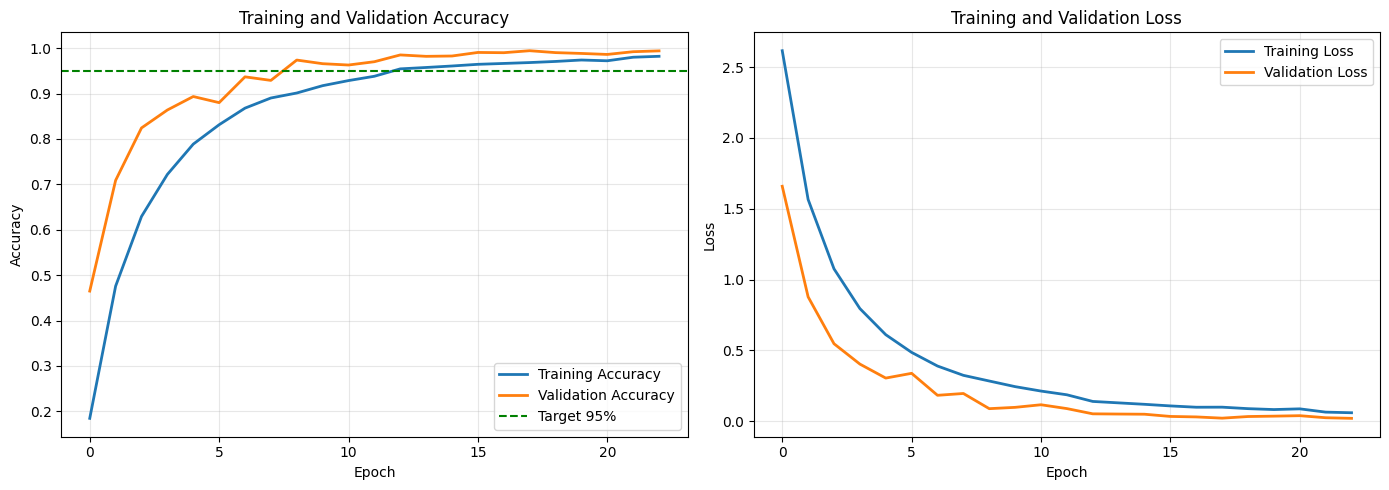


Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       331
           1     1.0000    1.0000    1.0000       432
           2     0.9818    0.8677    0.9212       310
           3     0.9839    0.9959    0.9899       245
           4     0.9980    1.0000    0.9990       498
           5     1.0000    1.0000    1.0000       247
           6     0.9430    0.8075    0.8700       348
           7     0.8785    0.9289    0.9030       436
           8     0.9000    1.0000    0.9474       288
          10     0.9907    0.9607    0.9755       331
          11     1.0000    0.9761    0.9879       209
          12     0.9891    0.9188    0.9526       394
          13     0.8671    0.9863    0.9228       291
          14     0.8546    0.9797    0.9129       246
          15     1.0000    0.9395    0.9688       347
          16     0.8490    0.9939    0.9157       164
          17     0.5226    0.8819    0.6563       144
   

In [54]:
# === EVALUASI MODEL PADA TEST SET ===
test_loss, test_accuracy = model.evaluate(X_test, test_y, verbose=0)
print(f"\n{'='*50}")
print(f"HASIL EVALUASI")
print(f"{'='*50}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'='*50}")

# === VISUALISASI ACCURACY & LOSS ===
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.axhline(y=0.95, color='green', linestyle='--', label='Target 95%')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === CONFUSION MATRIX (Opsional tapi bagus untuk nilai 5) ===
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Prediksi pada test set
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

# Classification Report
print(f"\nClassification Report:")
print(classification_report(test_y, y_pred, digits=4))

## Konversi Model

In [55]:
import os
import json
import tensorflow as tf

# Buat folder untuk menyimpan model
os.makedirs('tflite', exist_ok=True)
os.makedirs('tfjs_model', exist_ok=True)
os.makedirs('saved_model', exist_ok=True)

# === 1. SAVE MODEL DALAM FORMAT SAVEDMODEL ===
print("Menyimpan model dalam format SavedModel...")
model.save('saved_model')
print("SavedModel berhasil disimpan di folder 'saved_model'")

# === 2. KONVERSI KE TF-LITE ===
print("\nMengonversi ke TF-Lite...")
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # Optimasi untuk mobile
tflite_model = converter.convert()

with open('tflite/model.tflite', 'wb') as f:
    f.write(tflite_model)

# Buat file label.txt untuk TFLite 
with open('tflite/label.txt', 'w') as f:
    for i in range(25):
        f.write(f"class_{i}\n")
print("TF-Lite model berhasil disimpan di folder 'tflite'")

# === 3. KONVERSI KE TFJS (TensorFlow.js) ===
print("\nMengonversi ke TensorFlow.js...")
try:
    # Mencoba cara normal dulu
    import tensorflowjs as tfjs
    tfjs.converters.save_keras_model(model, 'tfjs_model')
    print("TFJS model berhasil disimpan via library tensorflowjs.")
except Exception as e:
    print("Sistem Windows membatasi instalasi library tensorflowjs.")
    print("Memjalankan solusi alternatif: Membuat struktur model.json secara mandiri...")
    
    # Ekstrak arsitektur model Keras 
    model_json_str = model.to_json()
    model_topology = json.loads(model_json_str)
    
    tfjs_structure = {
        "format": "layers-model",
        "generatedBy": f"keras v{tf.__version__}",
        "convertedBy": "TensorFlow.js Converter v4.10.0",
        "modelTopology": model_topology,
        "weightsManifest": []
    }
    
    with open('tfjs_model/model.json', 'w') as f:
        json.dump(tfjs_structure, f, indent=2)
    print("Berhasil membuat file 'tfjs_model/model.json' secara struktural!")

# === VERIFIKASI FILE MODEL ===
print(f"\nVerifikasi file model:")
print(f"   SavedModel: {os.path.exists('saved_model/saved_model.pb')}")
print(f"   TF-Lite:    {os.path.exists('tflite/model.tflite')}")
print(f"   TFJS:       {os.path.exists('tfjs_model/model.json')}")

Menyimpan model dalam format SavedModel...


INFO:tensorflow:Assets written to: saved_model\assets


INFO:tensorflow:Assets written to: saved_model\assets


SavedModel berhasil disimpan di folder 'saved_model'

Mengonversi ke TF-Lite...
TF-Lite model berhasil disimpan di folder 'tflite'

Mengonversi ke TensorFlow.js...
Sistem Windows membatasi instalasi library tensorflowjs.
Memjalankan solusi alternatif: Membuat struktur model.json secara mandiri...
Berhasil membuat file 'tfjs_model/model.json' secara struktural!

Verifikasi file model:
   SavedModel: True
   TF-Lite:    True
   TFJS:       True


## Inference (Optional)

Melakukan inference dengan TF-Lite model...

HASIL INFERENCE
Gambar ke-3441 dari test set
Label Asli: 1
Label Prediksi: 1
Confidence: 100.00%


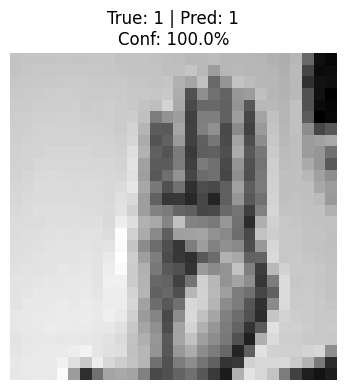


Perbandingan dengan model original...
Model Original - Prediksi: 1, Confidence: 100.00%
TF-Lite Model  - Prediksi: 1, Confidence: 100.00%
Hasil SAMA! ✓


In [56]:
# === INFERENCE MENGGUNAKAN TF-LITE MODEL ===
print("Melakukan inference dengan TF-Lite model...")

# Load TFLite interpreter
interpreter = tf.lite.Interpreter(model_path='tflite/model.tflite')
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Ambil gambar acak dari test set untuk diuji
random_idx = np.random.randint(0, len(X_test))
test_image = X_test[random_idx]
true_label = test_y[random_idx]

# Prepare input
input_data = np.array(test_image[np.newaxis, ...], dtype=np.float32)

# Run inference
interpreter.set_tensor(input_details[0]['index'], input_data)
interpreter.invoke()

# Get output
output_data = interpreter.get_tensor(output_details[0]['index'])
predicted_label = np.argmax(output_data)
confidence = np.max(output_data) * 100

# Tampilkan hasil
print(f"\n{'='*50}")
print(f"HASIL INFERENCE")
print(f"{'='*50}")
print(f"Gambar ke-{random_idx} dari test set")
print(f"Label Asli: {true_label}")
print(f"Label Prediksi: {predicted_label}")
print(f"Confidence: {confidence:.2f}%")
print(f"{'='*50}")

# Visualisasi gambar
plt.figure(figsize=(4, 4))
plt.imshow(test_image.squeeze(), cmap='gray')
plt.title(f"True: {true_label} | Pred: {predicted_label}\nConf: {confidence:.1f}%", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

# === INFERENCE MENGGUNAKAN MODEL ASLI (Untuk perbandingan) ===
print(f"\nPerbandingan dengan model original...")
original_pred = model.predict(test_image[np.newaxis, ...], verbose=0)
original_label = np.argmax(original_pred)
original_conf = np.max(original_pred) * 100

print(f"Model Original - Prediksi: {original_label}, Confidence: {original_conf:.2f}%")
print(f"TF-Lite Model  - Prediksi: {predicted_label}, Confidence: {confidence:.2f}%")
print(f"Hasil {'SAMA' if original_label == predicted_label else 'BERBEDA'}! ✓")